In [ ]:
DBSCAN - non parametric algo, epsilon distance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [4]:
df = pd.DataFrame(X, columns=['Feature1','Feature2'])

In [5]:
df

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [20]:
k_means_final = KMeans(n_clusters=2, random_state=42)
cluster_labels_kmeans = k_means_final.fit_predict(X_scaled)

In [21]:
df['kmean_cluster'] = cluster_labels_kmeans

<Axes: xlabel='Feature1', ylabel='Feature2'>

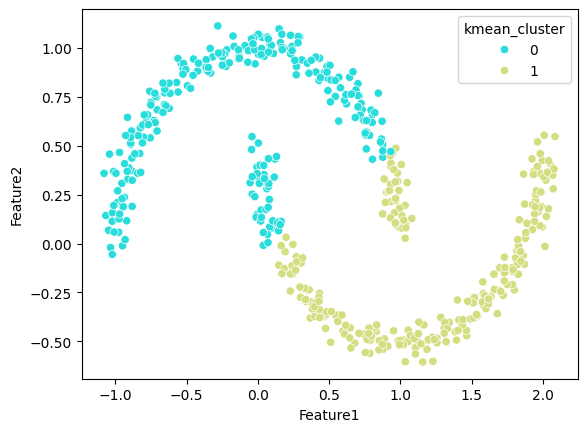

In [22]:
sns.scatterplot(x=df['Feature1'], y=df['Feature2'], hue=df['kmean_cluster'], palette='rainbow')

In [23]:
# Here above we can see the big problem with kmeans - Wrong Clusters

In [24]:
dbscan = DBSCAN(eps=0.3, min_samples=5)     # eps is the distance req to make cluster, min samples means number of data points to be there inside eps distance
cluster_labels_db = dbscan.fit_predict(X_scaled)

In [25]:
df['dbscan_cluster'] = cluster_labels_db

<Axes: xlabel='Feature1', ylabel='Feature2'>

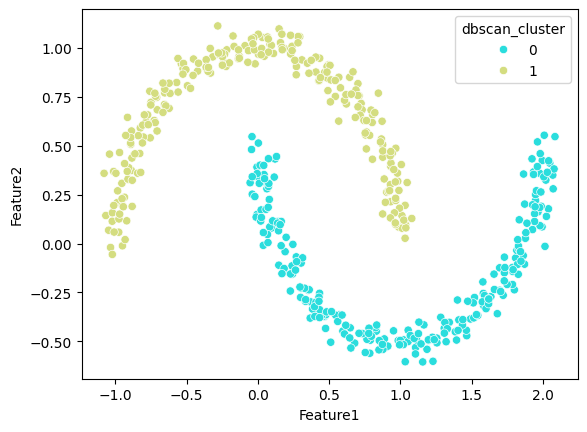

In [26]:
sns.scatterplot(x=df['Feature1'], y=df['Feature2'], hue=df['dbscan_cluster'], palette='rainbow')

In [27]:
# Here is the proper clusterinng of non-circular data using dbscan